Stronlgy inspired by https://squidpy.readthedocs.io/en/stable/notebooks/examples/graph/compute_nhood_enrichment.html

In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import networkx as nx

C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit6\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit6\.pixi\envs\default\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit6\.pixi\envs\default\Lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
label = "cluster"
#label = "cell type" 

In [3]:
adata = sq.datasets.visium_fluo_adata() 
#adata = sq.datasets.imc()

In [4]:
#plt.imshow(adata.uns["spatial"]['V1_Adult_Mouse_Brain_Coronal_Section_2']['images']['hires'])

C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit6\.pixi\envs\default\Lib\site-packages\squidpy\pl\_spatial_utils.py:468: FutureWarning: The method obs_vector is deprecated and will be removed in the future. Use anndata.acc.A instead of obs_vector. E.g. `vec = adata[A.obs['foo']]` or `vec = adata[A.layers['l']['bar', :]]`
  color_source_vector = adata.obs_vector(value_to_plot, layer=layer)
C:\Users\annam\Documents\compbiol_git\compbiol\bioimaging\Unit6\.pixi\envs\default\Lib\site-packages\squidpy\pl\_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


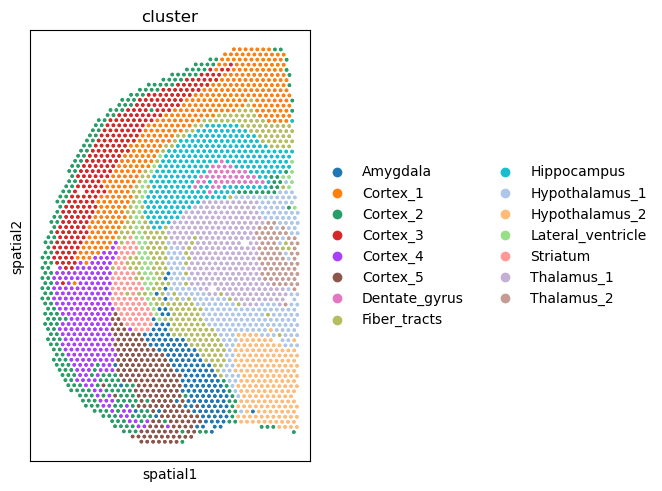

In [5]:
#sq.pl.spatial_scatter(adata, color="cluster")
sq.pl.spatial_scatter(adata, color=label, size=10, shape=None)

In [6]:
adata

AnnData object with n_obs × n_vars = 2800 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None

In [7]:
sq.gr.spatial_neighbors_knn(adata) # n_neighs
adata

INFO     Creating graph using `None` transform and `1` libraries.                                                  


AnnData object with n_obs × n_vars = 2800 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap', 'spatial_neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
    layers: None

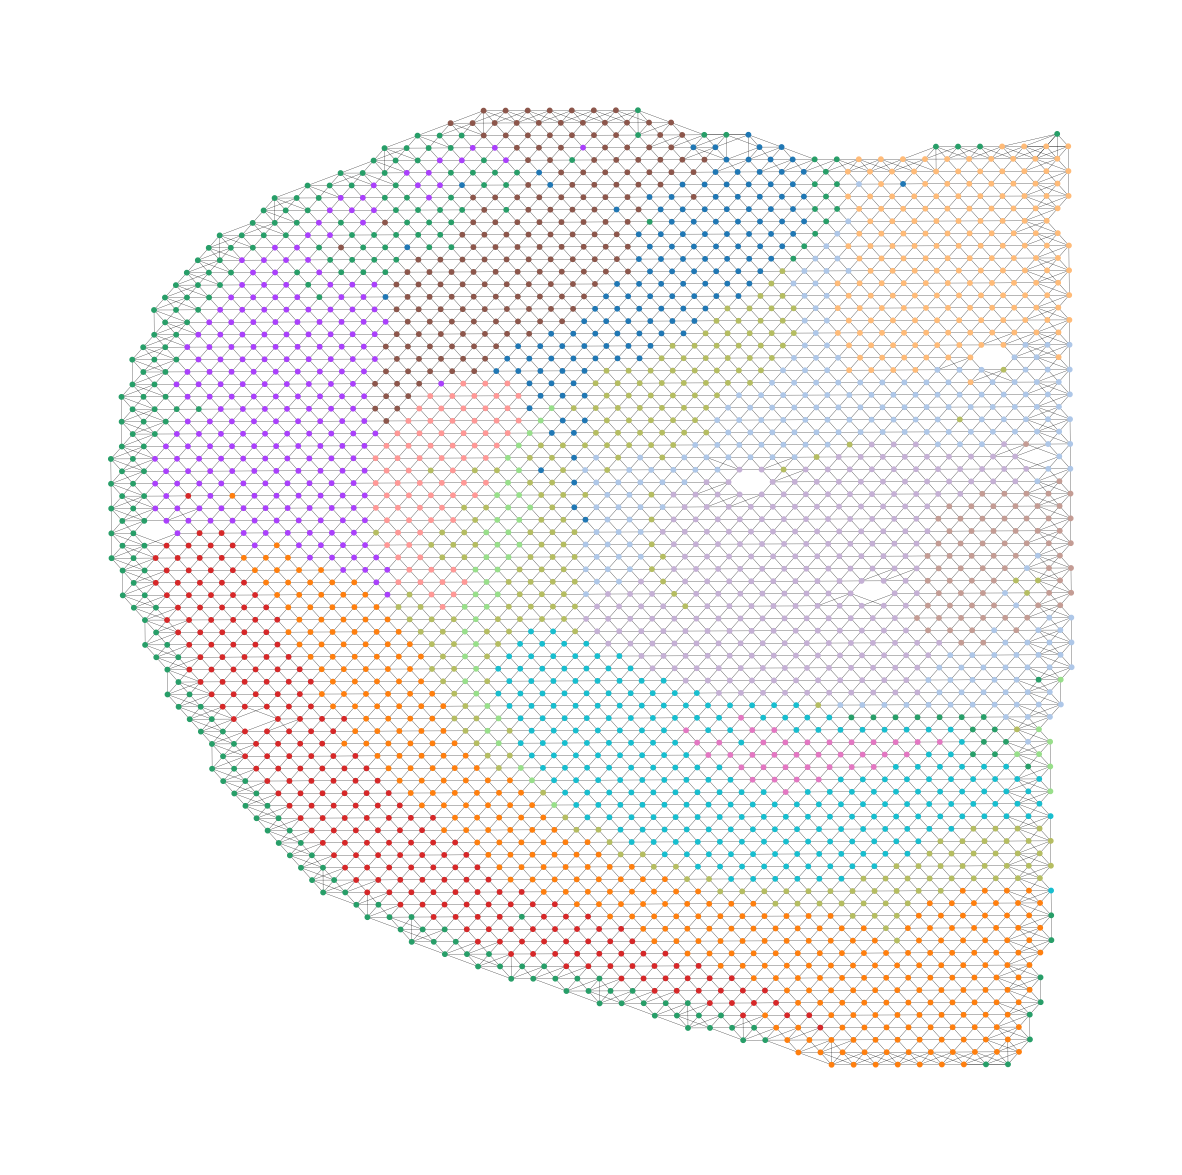

In [8]:
G = nx.from_scipy_sparse_array(adata.obsp["spatial_connectivities"])
pos = {i: adata.obsm["spatial"][i] for i in range(adata.n_obs)}
cluster_categories = adata.obs[label].cat.categories
cluster_colors = adata.uns[f"{label}_colors"]

color_map = dict(zip(cluster_categories, cluster_colors))
node_colors = adata.obs[label].map(color_map)

f, ax = plt.subplots(1, figsize=(15, 15))
nx.draw(G, pos=pos, node_color=node_colors, node_size=10, width=0.2, ax=ax)

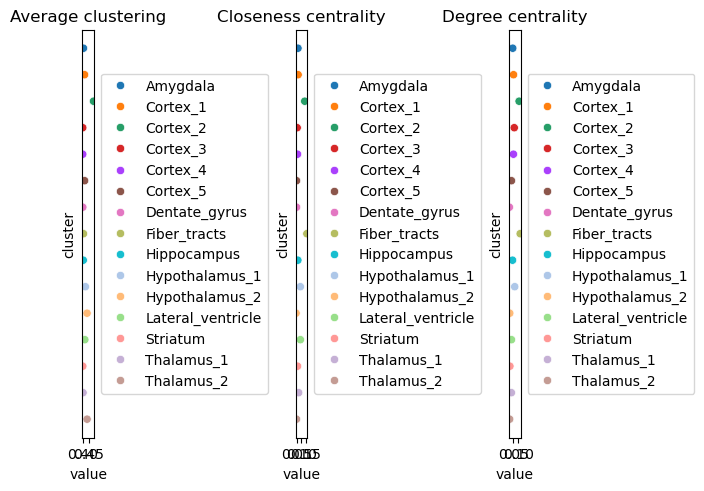

In [10]:
sq.gr.centrality_scores(adata, label)
sq.pl.centrality_scores(adata, label)

In [11]:
sq.gr.nhood_enrichment(adata, cluster_key=label)
adata

100%|██████████| 1000/1000 [00:06<00:00, 148.03/s]


AnnData object with n_obs × n_vars = 2800 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap', 'spatial_neighbors', 'cluster_centrality_scores', 'cluster_nhood_enrichment'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
    layers: No

AnnData object with n_obs × n_vars = 2800 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap', 'spatial_neighbors', 'cluster_centrality_scores', 'cluster_nhood_enrichment'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'
    layers: No

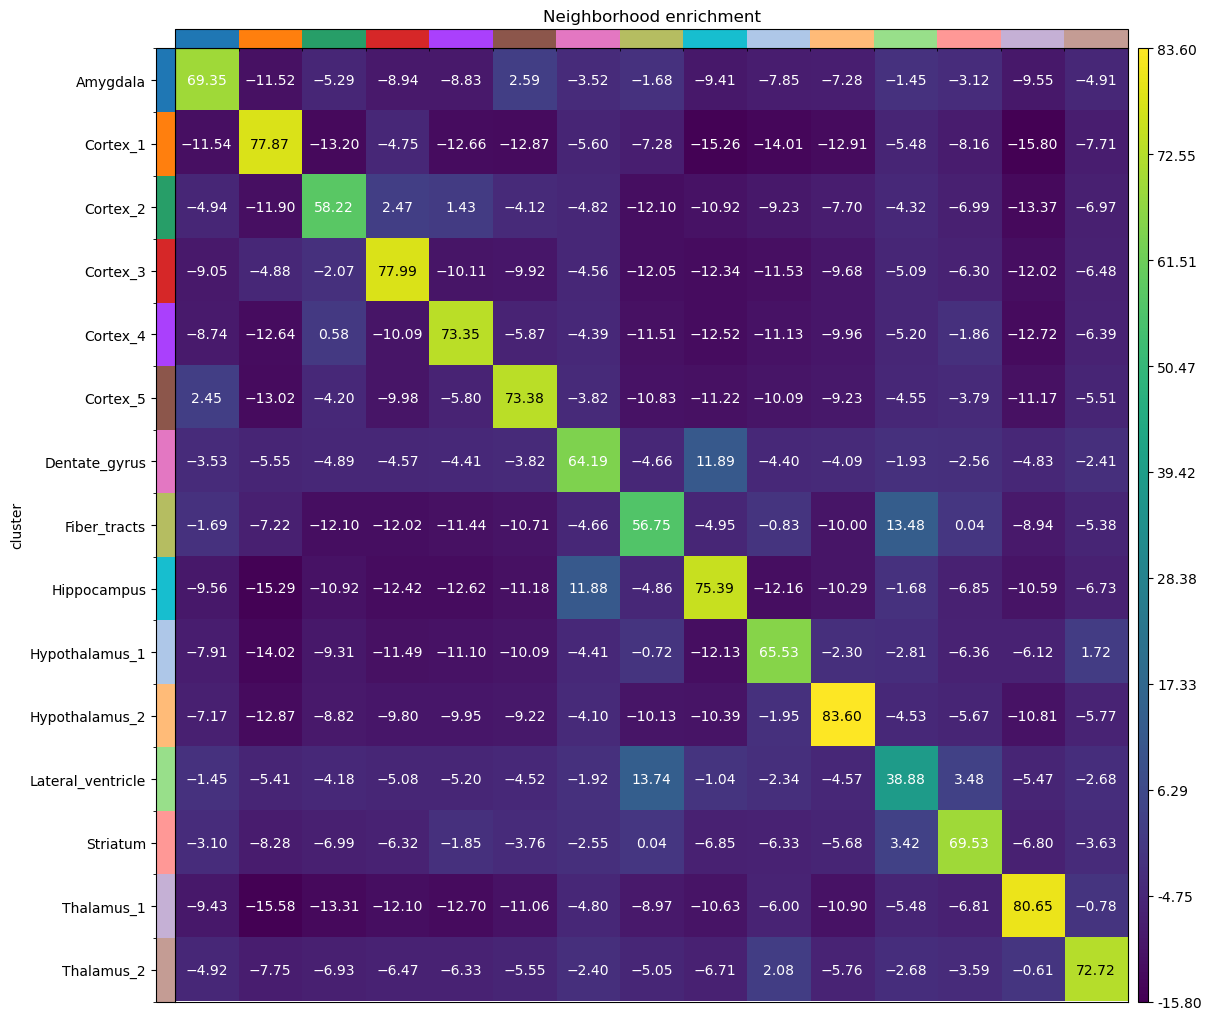

In [12]:
sq.pl.nhood_enrichment(adata, cluster_key=label, annotate=True)
adata